<a href="https://colab.research.google.com/github/Vanitha-Jain/capstone/blob/Feature-selection/MorganFP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data=pd.read_csv('/content/Morgan_fingerprint.csv')
data

,molecule_chembl_id,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,...,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,bioactivity_class
0,CHEMBL167155,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
1,CHEMBL166740,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
2,CHEMBL165038,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
3,CHEMBL435857,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
4,CHEMBL352783,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
1225,CHEMBL5436920,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
1226,CHEMBL5405698,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive
1227,CHEMBL5416562,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,inactive


In [ ]:
data.dtypes

,0
molecule_chembl_id,object
FP_0,int64
FP_1,int64
FP_2,int64
FP_3,int64
...,...
FP_2044,int64
FP_2045,int64
FP_2046,int64
FP_2047,int64


In [ ]:
data['bioactivity_class'].replace('active', 'P', inplace=True)
data['bioactivity_class'].replace('inactive', 'N', inplace=True)
data.rename(columns = {"bioactivity_class": "class"}, inplace = True)
data

<ipython-input-5-d75cbf56e791>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bioactivity_class'].replace('active', 'P', inplace=True)
<ipython-input-5-d75cbf56e791>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,molecule_chembl_id,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,...,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,class
0,CHEMBL167155,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1,CHEMBL166740,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
2,CHEMBL165038,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
3,CHEMBL435857,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
4,CHEMBL352783,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1225,CHEMBL5436920,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1226,CHEMBL5405698,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1227,CHEMBL5416562,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N


In [ ]:
data.isnull().sum().sum()

0

In [ ]:
data.dropna(inplace =True)
data.isnull().sum().sum()

0

In [ ]:
data1 = data.iloc[:,1:2049]
data1
data2 = data.iloc[:,-1]

In [ ]:
data1
data2

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
from sklearn.feature_selection import VarianceThreshold
threshold = VarianceThreshold(threshold=.1)
def variance_threshold_selector(data1, threshold=0.10):
    selector = VarianceThreshold(threshold)
    selector.fit(data1)
    return data[data1.columns[selector.get_support(indices=True)]]
data1_HV = variance_threshold_selector(data1)

In [ ]:
data1_HV = variance_threshold_selector(data1)
data1_HV

,FP_1,FP_45,FP_80,FP_114,FP_191,FP_249,FP_283,FP_294,FP_314,FP_322,...,FP_1816,FP_1823,FP_1825,FP_1855,FP_1866,FP_1911,FP_1917,FP_1928,FP_1956,FP_1970
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
1225,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
1226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
1227,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0


In [ ]:
data2_HV = pd.merge(data1_HV,data2,left_index=True,right_index=True)
data2_HV

,FP_1,FP_45,FP_80,FP_114,FP_191,FP_249,FP_283,FP_294,FP_314,FP_322,...,FP_1823,FP_1825,FP_1855,FP_1866,FP_1911,FP_1917,FP_1928,FP_1956,FP_1970,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,N
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,N
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,N
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,N
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,N
1225,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,N
1226,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,N
1227,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,N


In [ ]:
## remove features that display high correlation with many other features
correlated_features_1 = set()
corr_matrix_class = data2_HV.corr(numeric_only=True)


for i in range(len(corr_matrix_class.columns)):
    for j in range(i):
        if abs(corr_matrix_class.iloc[i, j]) > 0.8:
            colname = corr_matrix_class.columns[i]
            correlated_features_1.add(colname)
correlated_features_1

{'FP_1536', 'FP_1683', 'FP_1970', 'FP_283'}

In [ ]:
def remove_correlated_features(features, data):
    for x in features:
        data.drop(x, axis=1, inplace=True)
    return data

In [ ]:
data3= remove_correlated_features(correlated_features_1, data2_HV)
data3

,FP_1,FP_45,FP_80,FP_114,FP_191,FP_249,FP_294,FP_314,FP_322,FP_350,...,FP_1816,FP_1823,FP_1825,FP_1855,FP_1866,FP_1911,FP_1917,FP_1928,FP_1956,class
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,N
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,N
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,N
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,N
4,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,1,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,N
1225,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,N
1226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,N
1227,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,N


In [ ]:
data3.to_csv('MorganFP.csv')

In [ ]:
X = data3.iloc[:,1:73]  #independent columns
X
y = data3.iloc[:,-1]
y   #target column i.e price range

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
X

,FP_45,FP_80,FP_114,FP_191,FP_249,FP_294,FP_314,FP_322,FP_350,FP_352,...,FP_1754,FP_1816,FP_1823,FP_1825,FP_1855,FP_1866,FP_1911,FP_1917,FP_1928,FP_1956
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
1225,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
1226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
1227,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
# y = data['class']
# X_features =data.drop(columns='class')
scaler = StandardScaler()
X_transform = scaler.fit_transform(X)
X_transform_pd = pd.DataFrame(X_transform, columns = X.columns)
X_transform_pd

# #Standardize/normalize the data
# from sklearn.preprocessing import MinMaxScaler
# sc = MinMaxScaler()
# X_transform = sc.fit_transform(X)
# X_transform

,FP_45,FP_80,FP_114,FP_191,FP_249,FP_294,FP_314,FP_322,FP_350,FP_352,...,FP_1754,FP_1816,FP_1823,FP_1825,FP_1855,FP_1866,FP_1911,FP_1917,FP_1928,FP_1956
0,-0.377085,-1.315717,-0.362872,-0.359994,-0.45657,-0.455268,-0.769395,-0.56952,2.360549,-0.452661,...,-0.416929,-0.473396,-0.371434,-0.427631,-0.712724,-0.393796,-0.386875,0.942266,-0.486229,-0.357104
1,-0.377085,-1.315717,-0.362872,-0.359994,-0.45657,-0.455268,-0.769395,-0.56952,2.360549,-0.452661,...,-0.416929,-0.473396,-0.371434,-0.427631,-0.712724,-0.393796,-0.386875,0.942266,-0.486229,-0.357104
2,-0.377085,-1.315717,-0.362872,-0.359994,-0.45657,-0.455268,-0.769395,-0.56952,2.360549,-0.452661,...,-0.416929,-0.473396,-0.371434,-0.427631,-0.712724,-0.393796,-0.386875,0.942266,-0.486229,-0.357104
3,-0.377085,-1.315717,-0.362872,-0.359994,-0.45657,-0.455268,-0.769395,-0.56952,2.360549,-0.452661,...,-0.416929,-0.473396,-0.371434,-0.427631,-0.712724,-0.393796,-0.386875,0.942266,-0.486229,-0.357104
4,-0.377085,-1.315717,-0.362872,-0.359994,-0.45657,-0.455268,-0.769395,-0.56952,2.360549,-0.452661,...,-0.416929,-0.473396,2.692271,-0.427631,-0.712724,-0.393796,-0.386875,0.942266,-0.486229,-0.357104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,-0.377085,-1.315717,-0.362872,-0.359994,-0.45657,-0.455268,-0.769395,-0.56952,-0.423630,-0.452661,...,-0.416929,-0.473396,-0.371434,-0.427631,1.403068,2.539387,-0.386875,-1.061272,-0.486229,-0.357104
1225,-0.377085,-1.315717,-0.362872,-0.359994,-0.45657,-0.455268,-0.769395,-0.56952,-0.423630,-0.452661,...,-0.416929,-0.473396,-0.371434,-0.427631,1.403068,2.539387,-0.386875,-1.061272,-0.486229,-0.357104
1226,-0.377085,-1.315717,-0.362872,-0.359994,-0.45657,-0.455268,-0.769395,-0.56952,-0.423630,-0.452661,...,-0.416929,-0.473396,-0.371434,-0.427631,1.403068,2.539387,-0.386875,-1.061272,-0.486229,-0.357104
1227,-0.377085,-1.315717,-0.362872,-0.359994,-0.45657,-0.455268,-0.769395,-0.56952,-0.423630,-0.452661,...,-0.416929,-0.473396,-0.371434,-0.427631,1.403068,2.539387,-0.386875,-1.061272,-0.486229,-0.357104


In [ ]:
## Split data into train and test sets.
from sklearn.model_selection import train_test_split
seed_num = 10
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=seed_num)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(860, 72)
(860,)
(369, 72)
(369,)


In [ ]:
X_train

,FP_45,FP_80,FP_114,FP_191,FP_249,FP_294,FP_314,FP_322,FP_350,FP_352,...,FP_1754,FP_1816,FP_1823,FP_1825,FP_1855,FP_1866,FP_1911,FP_1917,FP_1928,FP_1956
387,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
250,1,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
378,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
73,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1185,0,0,0,0,1,0,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
1180,0,1,0,0,1,0,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0
1147,0,1,1,0,1,0,0,0,0,0,...,1,0,0,0,0,0,1,1,1,0
527,0,1,0,0,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,1


In [ ]:
y_train

,class
387,N
250,N
378,N
73,N
1185,P
...,...
733,N
1180,P
1147,N
527,P


In [ ]:
Training_set  = pd.concat([X_train,y_train],axis=1)
Training_set

,FP_45,FP_80,FP_114,FP_191,FP_249,FP_294,FP_314,FP_322,FP_350,FP_352,...,FP_1816,FP_1823,FP_1825,FP_1855,FP_1866,FP_1911,FP_1917,FP_1928,FP_1956,class
387,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,N
250,1,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,N
378,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,N
73,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,N
1185,0,0,0,0,1,0,0,1,0,0,...,1,0,0,0,1,0,1,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,1,0,0,N
1180,0,1,0,0,1,0,0,1,0,0,...,1,0,0,0,1,0,1,0,0,P
1147,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,N
527,0,1,0,0,0,0,1,0,1,0,...,0,1,0,0,0,0,0,0,1,P


In [ ]:
Training_set.to_csv('MorganFP_Training_set.csv')

In [ ]:
Testing_set  = pd.concat([X_test,y_test],axis=1)
Testing_set

,FP_45,FP_80,FP_114,FP_191,FP_249,FP_294,FP_314,FP_322,FP_350,FP_352,...,FP_1816,FP_1823,FP_1825,FP_1855,FP_1866,FP_1911,FP_1917,FP_1928,FP_1956,class
693,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,N
834,1,1,0,0,0,0,0,1,0,1,...,0,0,1,1,0,0,0,0,1,N
1016,0,0,0,0,0,0,0,1,0,0,...,1,0,0,1,0,0,1,0,0,P
1113,0,1,0,0,1,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,P
31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0,0,0,1,0,0,0,0,1,0,...,0,0,1,1,0,0,0,1,0,P
909,0,1,0,0,0,0,1,1,0,0,...,1,1,0,1,1,0,1,0,0,P
270,1,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,N
349,0,1,1,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,P


In [ ]:
Testing_set.to_csv('MorganFP_Testing_set.csv')

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
kBest = SelectKBest(mutual_info_classif, k = 15)
X_kBestFeatures = kBest.fit_transform(X_train, y_train)
X_kBestFeatures.shape

(860, 15)

In [ ]:
kBest.get_support(True)

array([ 3,  4, 10, 20, 24, 26, 29, 33, 41, 46, 56, 60, 63, 69, 71])

In [ ]:
X_kBestFeatures = Training_set.iloc[:, kBest.get_support(True)]
X_kBestFeatures.columns

Index(['FP_191', 'FP_249', 'FP_361', 'FP_695', 'FP_807', 'FP_841', 'FP_935',
       'FP_1039', 'FP_1152', 'FP_1236', 'FP_1480', 'FP_1738', 'FP_1816',
       'FP_1917', 'FP_1956'],
      dtype='object')

In [ ]:
f = kBest.get_support(1)
X_new = X_train[X_train.columns[f]]
X_new
data_scores = pd.DataFrame(kBest.scores_)
data_columns = pd.DataFrame(X.columns)

In [ ]:
#Concat two dataframes for better visualization
featureScores = pd.concat([data_columns, data_scores], axis = 1)

#naming the dataframe columns
featureScores.columns = ['Features', 'Scores']
featureScores

,Features,Scores
0,FP_45,0.002489
1,FP_80,0.001247
2,FP_114,0.023648
3,FP_191,0.025603
4,FP_249,0.066682
...,...,...
67,FP_1866,0.002764
68,FP_1911,0.000000
69,FP_1917,0.024652
70,FP_1928,0.005451


In [ ]:
#Print top 25 best features
print(featureScores.nlargest(15, 'Scores'))

   Features    Scores
26   FP_841  0.076184
4    FP_249  0.066682
63  FP_1816  0.058237
20   FP_695  0.058071
10   FP_361  0.045109
24   FP_807  0.039208
71  FP_1956  0.038527
56  FP_1480  0.034945
60  FP_1738  0.031421
46  FP_1236  0.030640
33  FP_1039  0.030288
29   FP_935  0.029981
3    FP_191  0.025603
41  FP_1152  0.025284
69  FP_1917  0.024652


In [ ]:
Graph = (featureScores.nlargest(15, 'Scores'))
Graph

,Features,Scores
26,FP_841,0.076184
4,FP_249,0.066682
63,FP_1816,0.058237
20,FP_695,0.058071
10,FP_361,0.045109
24,FP_807,0.039208
71,FP_1956,0.038527
56,FP_1480,0.034945
60,FP_1738,0.031421
46,FP_1236,0.030640


In [ ]:
Graph.to_csv('MorganFP_Features.csv')

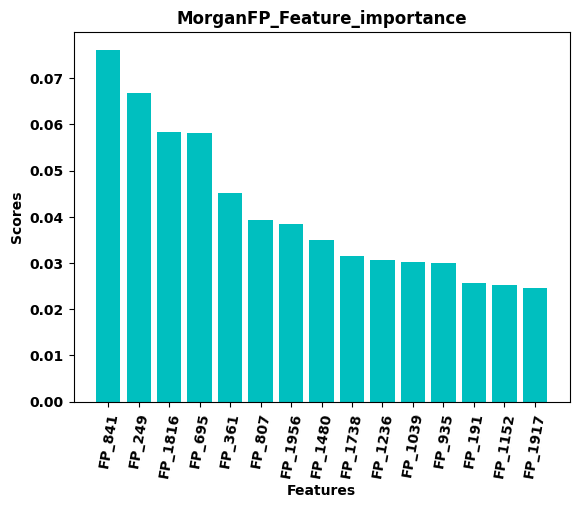

<Figure size 1000x1000 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
data = pd.read_csv('MorganFP_Features.csv')
df = pd.DataFrame(data)
X = list(df.iloc[:, 1])
Y = list(df.iloc[:, 2])
plt.bar(X, Y, color='c')
plt.title("MorganFP_Feature_importance", fontweight="bold")
plt.xlabel("Features", fontweight = 'bold')
plt.ylabel("Scores", fontweight = 'bold')
plt.xticks(rotation = 80, fontweight="bold")
plt.yticks(fontweight="bold")
fig = plt.figure(figsize=(10, 10))
plt.savefig("Features.jpg", bbox_inches = 'tight')

In [ ]:
Trainset = pd.concat([X_new,y_train],axis=1)
Trainset

,FP_191,FP_249,FP_361,FP_695,FP_807,FP_841,FP_935,FP_1039,FP_1152,FP_1236,FP_1480,FP_1738,FP_1816,FP_1917,FP_1956,class
387,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,N
250,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,N
378,0,0,0,0,1,0,1,0,1,0,0,1,0,0,0,N
73,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,N
1185,0,1,0,1,1,1,0,0,1,0,0,0,1,1,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,1,1,0,1,0,0,0,1,0,0,1,0,N
1180,0,1,0,1,1,1,1,0,1,0,1,0,1,1,0,P
1147,0,1,0,1,1,0,1,0,0,0,1,0,0,1,0,N
527,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,P


In [ ]:
f = kBest.get_support(1)
Test_new = X_test[X_test.columns[f]]
Test_new

,FP_191,FP_249,FP_361,FP_695,FP_807,FP_841,FP_935,FP_1039,FP_1152,FP_1236,FP_1480,FP_1738,FP_1816,FP_1917,FP_1956
693,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
834,0,0,0,1,0,1,1,1,0,0,0,0,0,0,1
1016,0,0,0,1,1,1,0,0,1,0,0,0,1,1,0
1113,0,1,0,1,1,1,0,1,0,0,0,0,0,1,0
31,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,1,0,0,0,0,0,1,0,1,1,1,0,0,0,0
909,0,0,0,1,1,0,1,0,1,1,1,1,1,1,0
270,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
349,0,0,0,1,1,1,1,0,0,0,1,1,0,0,0


In [ ]:
Testset = pd.concat([Test_new,y_test],axis=1)
Testset

,FP_191,FP_249,FP_361,FP_695,FP_807,FP_841,FP_935,FP_1039,FP_1152,FP_1236,FP_1480,FP_1738,FP_1816,FP_1917,FP_1956,class
693,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,N
834,0,0,0,1,0,1,1,1,0,0,0,0,0,0,1,N
1016,0,0,0,1,1,1,0,0,1,0,0,0,1,1,0,P
1113,0,1,0,1,1,1,0,1,0,0,0,0,0,1,0,P
31,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,1,0,0,0,0,0,1,0,1,1,1,0,0,0,0,P
909,0,0,0,1,1,0,1,0,1,1,1,1,1,1,0,P
270,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,N
349,0,0,0,1,1,1,1,0,0,0,1,1,0,0,0,P


In [ ]:
Trainset.to_csv('Trainset_MorganFP_after_feature.csv')
Testset.to_csv('Testset_MorganFP_after_feature.csv')

In [ ]:
Trainset['class'].replace('N', 0, inplace=True)
Trainset['class'].replace('P', 1, inplace=True)
Trainset.rename(columns = {"class": "class"}, inplace = True)
Trainset

<ipython-input-42-e976ed617192>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Trainset['class'].replace('N', 0, inplace=True)
<ipython-input-42-e976ed617192>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,FP_191,FP_249,FP_361,FP_695,FP_807,FP_841,FP_935,FP_1039,FP_1152,FP_1236,FP_1480,FP_1738,FP_1816,FP_1917,FP_1956,class
387,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
250,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0
378,0,0,0,0,1,0,1,0,1,0,0,1,0,0,0,0
73,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1185,0,1,0,1,1,1,0,0,1,0,0,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,0,0,0,1,1,0,1,0,0,0,1,0,0,1,0,0
1180,0,1,0,1,1,1,1,0,1,0,1,0,1,1,0,1
1147,0,1,0,1,1,0,1,0,0,0,1,0,0,1,0,0
527,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,1


In [ ]:
Testset['class'].replace('N', 0, inplace=True)
Testset['class'].replace('P', 1, inplace=True)
Testset.rename(columns = {"class": "class"}, inplace = True)
Testset.head()

<ipython-input-43-c538cf0d9b31>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Testset['class'].replace('N', 0, inplace=True)
<ipython-input-43-c538cf0d9b31>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,FP_191,FP_249,FP_361,FP_695,FP_807,FP_841,FP_935,FP_1039,FP_1152,FP_1236,FP_1480,FP_1738,FP_1816,FP_1917,FP_1956,class
693,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
834,0,0,0,1,0,1,1,1,0,0,0,0,0,0,1,0
1016,0,0,0,1,1,1,0,0,1,0,0,0,1,1,0,1
1113,0,1,0,1,1,1,0,1,0,0,0,0,0,1,0,1
31,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
Trainset.to_csv('Trainset1_MorganFP_after_feature.csv')
Testset.to_csv('Testset1_MorganFP_after_feature.csv')